In [3]:
import numpy as np
import pandas as pd

import scanpy as sc
import scvelo as scv

import matplotlib.pyplot as plt
import seaborn as sns

import myutils

import random
import os

myutils.set_figure_params()
sc.settings.verbosity = 3

In [4]:
adata_M = sc.read_h5ad("4.1.final_M.h5ad")
adata_M

AnnData object with n_obs × n_vars = 5738 × 25998
    obs: 'cell_id', 'sample', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_counts', 'condition', 'leiden', 'CellType', 'condition_final', 'leiden1.0', 'umap_density_condition', 'M1_score', 'M2_score', 'CellType2'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'CellType2_colors', 'CellType_colors', 'condition_colors', 'hvg', 'leiden', 'leiden1.0', 'leiden1.0_colors', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'sample_colors', 'umap', 'umap_density_condition_params'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [5]:
all_colors = ["#96C3D8","#5D9BBE","#F5B375","#C0937E","#67A59B","#A4D38E","#4A9D47","#F19294","#E45A5F","#3477A9","#BDA7CB","#684797","#9983B7","#CD9A99","#DD4B52","#DA8F6F","#F58135"]
#all_colors = ["#96C3D8","#5D9BBE","#F5B375","#67A59B","#A4D38E","#4A9D47","#F19294","#E45A5F","#3477A9","#BDA7CB","#684797","#9983B7","#CD9A99","#DD4B52","#DA8F6F","#F58135"]
all_colors = np.array(all_colors)
use_colors = np.linspace(0,len(all_colors)-1,len(adata_M.obs['CellType2'].unique()))
use_colors = np.array(use_colors,dtype="int")
use_colors = all_colors[use_colors]
adata_M.uns['CellType2_colors'] = use_colors
#adata.uns['CellType_colors'] = use_colors

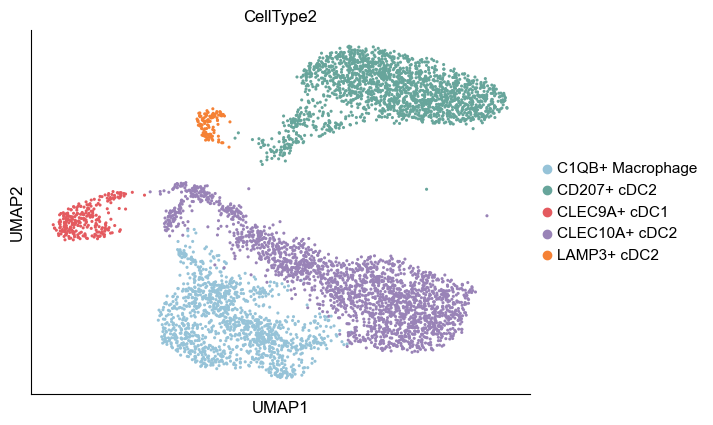

In [6]:
fig,ax = plt.subplots()
sc.pl.umap(adata_M,color="CellType2",ax=ax,show=False,size=20.)
fig.savefig("4.2.Figure1G.pdf",format="pdf",bbox_inches="tight")
plt.show()

In [7]:
adata = adata_M
print((adata.obs['condition']=="NS").sum(),(adata.obs['condition']=="Scar/keloid").sum())

1604 4134


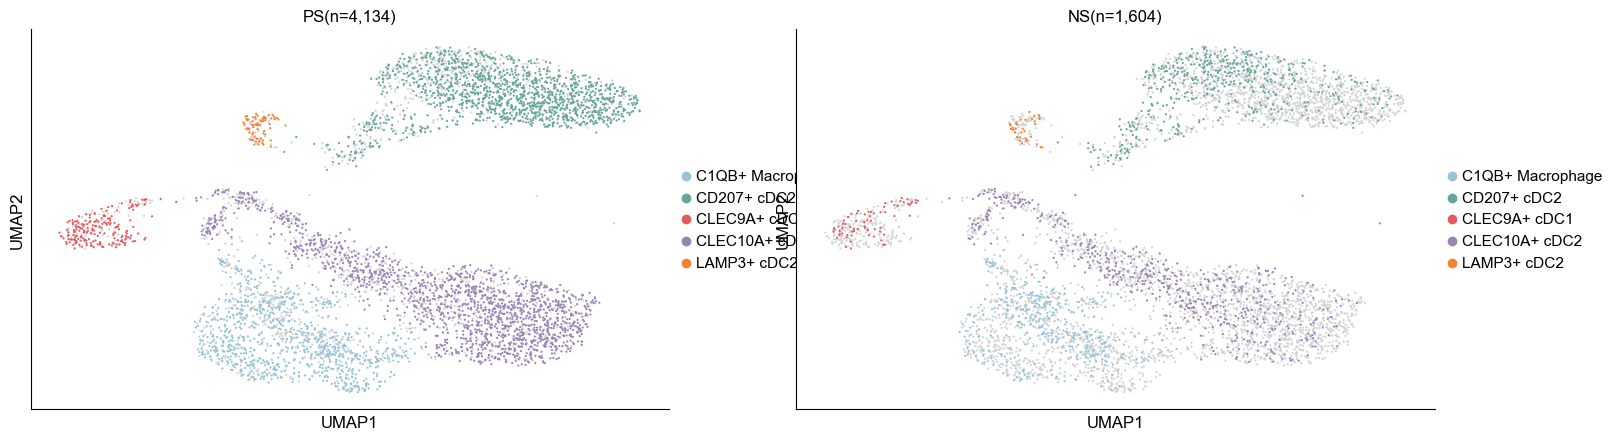

In [10]:
fig,axs = plt.subplots(1,2)
fig.set_figheight(5)
fig.set_figwidth(18)

adata = adata_M
sc.pl.embedding(adata[adata.obs['condition']!="Scar/keloid"],"umap",ax=axs[0],show=False,size=10.,title=None)
sc.pl.embedding(adata[adata.obs['condition']=="Scar/keloid"],"umap",color=["CellType2"],ax=axs[0],show=False,size=10.,title=None)
axs[0].set_title("PS(n=4,134)")

sc.pl.embedding(adata[adata.obs['condition']!="NS"],"umap",ax=axs[1],show=False,size=10.,title=None)
sc.pl.embedding(adata[adata.obs['condition']=="NS"],"umap",color=["CellType2"],ax=axs[1],show=False,size=10.,title=None)
axs[1].set_title("NS(n=1,604)")

fig.savefig("4.2.FigureS1I.pdf",format="pdf",bbox_inches="tight")
fig.show()

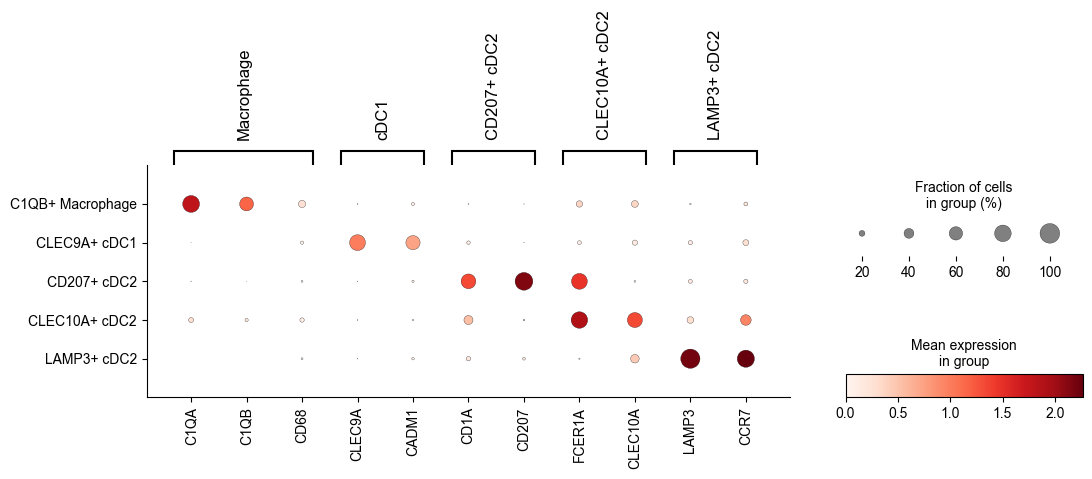

In [11]:
fig, ax = plt.subplots()
markers = {"Macrophage":["C1QA","C1QB","CD68"],
          "cDC1":["CLEC9A","CADM1"],
          "CD207+ cDC2":["CD1A","CD207"],
          "CLEC10A+ cDC2":["FCER1A","CLEC10A"],
          "LAMP3+ cDC2":["LAMP3","CCR7"]}
sc.pl.dotplot(adata_M, markers,groupby="CellType2",show=False,ax=ax, categories_order=["C1QB+ Macrophage","CLEC9A+ cDC1","CD207+ cDC2","CLEC10A+ cDC2","LAMP3+ cDC2"])
fig.savefig("4.2.FigureS1K.pdf",format="pdf",bbox_inches="tight")
fig.set_figwidth(12)
plt.show()

In [12]:
fig,ax = plt.subplots()
fig.set_figheight(12)
fig.set_figwidth(0.3)
#colors_list = np.array(['#1f77b4','#ff7f0e','#279e68','#aa40fc','#8c564b','#e377c2','#b5bd61','#17becf','#d62728'])
colors_list = adata.uns['CellType2_colors']
condition = ("CellType2")
celltypes = markers.keys()

heights = {}
for celltype in celltypes:
    heights[celltype] = len(markers[celltype])
    
colors = {}
for i, celltype in enumerate(celltypes):
    colors[celltype] = colors_list[i]

width = 0.2
bottom = np.zeros(1)

for celltype, height in heights.items():
    p = ax.bar(condition, height, width, label=celltype, bottom=bottom,facecolor=colors[celltype],linewidth=1.,edgecolor="black")
    bottom += height
#ax.legend(bbox_to_anchor=(1.0, 1.0))
ax.grid(False)
ax.axis(False)
fig.savefig("4.2.FigureS1K_bar.pdf",format="pdf",bbox_inches="tight")
plt.close()

In [13]:
tmp = myutils.tl.calculate_cell_fraction(adata_M,group_by="CellType2",sample_key="condition")
tmp.head(3)

,C1QB+ Macrophage,CD207+ cDC2,CLEC10A+ cDC2,CLEC9A+ cDC1,LAMP3+ cDC2,condition,n_cells
0,0.263092,0.311721,0.358479,0.044888,0.02182,NS,1604
1,0.217949,0.339865,0.378326,0.045960,0.01790,Scar/keloid,4134


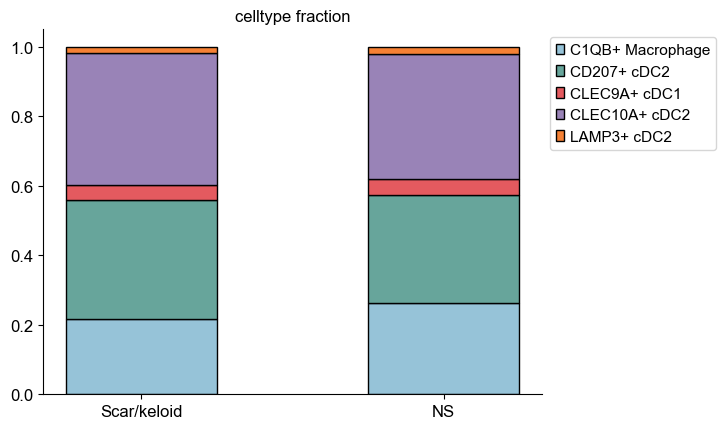

In [14]:
condition = ("Scar/keloid","NS")
tmp.index = tmp['condition']
tmp = tmp.loc[condition,:]

celltypes = ["C1QB+ Macrophage","CD207+ cDC2","CLEC9A+ cDC1","CLEC10A+ cDC2","LAMP3+ cDC2"]

heights = {}
for celltype in celltypes:
    heights[celltype] = tmp[celltype].to_numpy()
    
colors = {}
for i, celltype in enumerate(celltypes):
    colors[celltype] = adata.uns['CellType2_colors'][i]

width = 0.5

fig, ax = plt.subplots()
bottom = np.zeros(2)

for celltype, height in heights.items():
    p = ax.bar(condition, height, width, label=celltype, bottom=bottom,facecolor=colors[celltype],linewidth=1.,edgecolor="black")
    bottom += height
ax.grid(False)
ax.set_title("celltype fraction")
ax.legend(bbox_to_anchor=(1.0, 1.0))
fig.savefig("4.2.FigureS1J.pdf",format="pdf",bbox_inches="tight")
plt.show()

In [15]:
sc.pp.scale(adata_M)

... as `zero_center=True`, sparse input is densified and may lead to large memory consumption


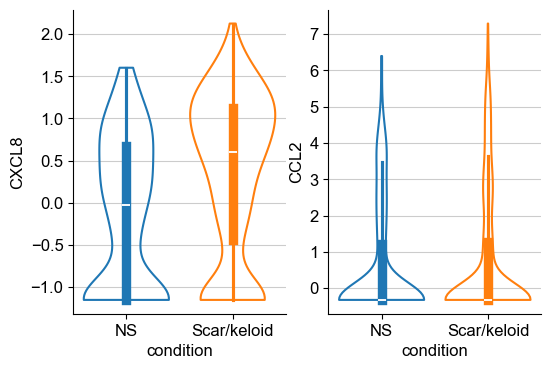

In [17]:
fig,axs = plt.subplots(1,2)
fig.set_figheight(4)
fig.set_figwidth(6)
function_genes = ["CXCL8","CCL2"]
for i, gene in enumerate(function_genes):
    sc.pl.violin(adata_M[adata_M.obs['CellType2'].isin(["C1QB+ Macrophage"])],groupby="condition",keys=gene,ax=axs[i],show=False,stripplot=False,inner="box",fill=False)
fig.savefig("4.2.Figure1J.pdf",format="pdf",bbox_inches="tight")
fig.show()

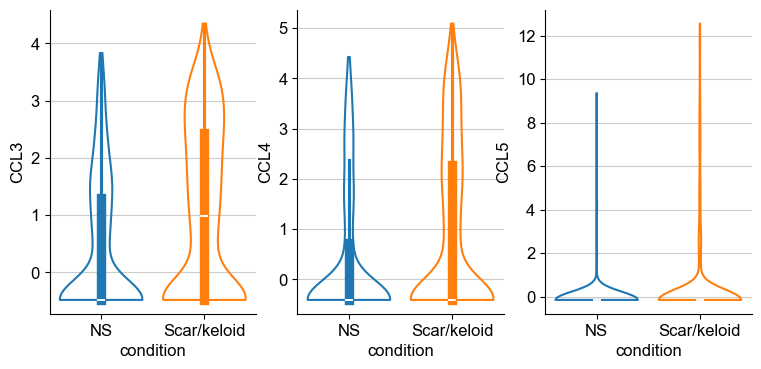

In [18]:
fig,axs = plt.subplots(1,3)
fig.set_figheight(4)
fig.set_figwidth(9)
function_genes = ["CCL3","CCL4","CCL5"]
for i, gene in enumerate(function_genes):
    sc.pl.violin(adata_M[adata_M.obs['CellType2'].isin(["C1QB+ Macrophage"])],groupby="condition",keys=gene,ax=axs[i],show=False,stripplot=False,inner="box",fill=False)
fig.savefig("4.2.FigureS1L.pdf",format="pdf",bbox_inches="tight")
fig.show()

In [19]:
import decoupler as dc

In [32]:
msigdb = dc.read_gmt("../../../Data/msigdb_v2024.1.Hs_GMTs/c5.go.bp.v2024.1.Hs.symbols.gmt")
msigdb = msigdb[~msigdb.duplicated(['source',"target"])]
tmp = []
for i in msigdb['source']:
    if "_" in i:
        tmp.append(i[:i.find("_")])
    else:
        tmp.append(i)
msigdb['collection']=tmp
print(msigdb['collection'].unique().tolist())

['GOBP']


In [33]:
markers = myutils.tl.scanpy_ranking_genes(adata_M[adata_M.obs['CellType2'].isin(["C1QB+ Macrophage"])],group_by="condition",calculate_average_expression=False)
markers

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


,NS_names,NS_scores,NS_pvals_adj,NS_logfoldchanges,Scar/keloid_names,Scar/keloid_scores,Scar/keloid_pvals_adj,Scar/keloid_logfoldchanges
0,DCD,21.388893,9.005122e-72,NaN,COL1A2,14.228707,1.262455e-38,NaN
1,CST3,12.766809,3.785784e-30,NaN,SPARC,12.766998,3.572923e-31,NaN
2,KRT10,11.184274,3.951552e-23,NaN,SOD2,12.297053,1.431686e-28,NaN
3,KRT1,10.208722,2.504215e-19,NaN,COL3A1,12.234269,8.968564e-29,NaN
4,SELENOP,9.070840,1.495482e-15,1.297365,COL1A1,11.979407,6.902948e-28,NaN
...,...,...,...,...,...,...,...,...
25993,COL1A1,-11.979407,6.902948e-28,NaN,SELENOP,-9.070840,1.495482e-15,-1.297365
25994,COL3A1,-12.234269,8.968564e-29,NaN,KRT1,-10.208722,2.504215e-19,NaN
25995,SOD2,-12.297053,1.431686e-28,NaN,KRT10,-11.184274,3.951552e-23,NaN
25996,SPARC,-12.766998,3.572923e-31,NaN,CST3,-12.766809,3.785784e-30,NaN


In [35]:
enr_pvals = dc.get_ora_df(
    df=markers['Scar/keloid_names'].head(200).tolist(),
    net=msigdb, 
    source='source',
    target='target',
)
enr_pvals = enr_pvals.sort_values("FDR p-value",ascending=True)
enr_pvals["-log10 p-value"] = - np.log10(enr_pvals['p-value'])
enr_pvals['Term2'] = [i.replace("GOBP_", "") for i in enr_pvals['Term']]
enr_pvals['Term2'] = [i.replace("_", " ") for i in enr_pvals['Term2']]
enr_pvals['Term2'] = [i.lower() for i in enr_pvals['Term2']]

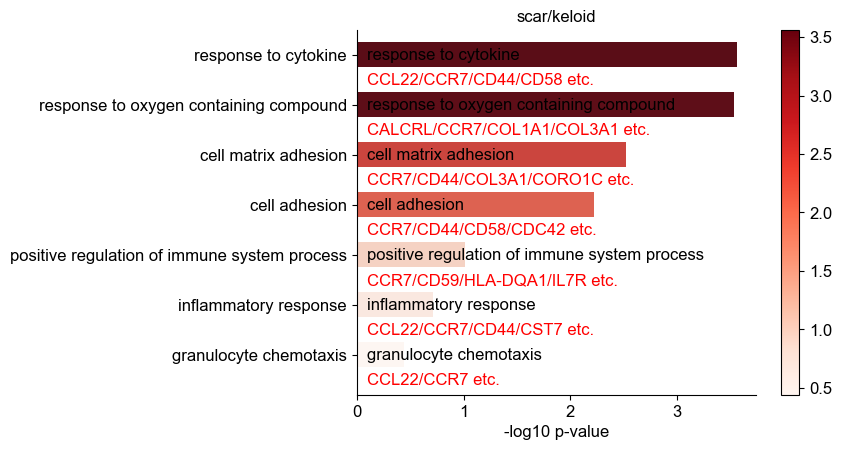

In [36]:
use_paths = ["response to cytokine","granulocyte chemotaxis","cell matrix adhesion","positive regulation of immune system process","cell adhesion","response to oxygen containing compound","inflammatory response"]
tmp = enr_pvals[enr_pvals['Term2'].isin(use_paths)]
a = tmp["-log10 p-value"]/tmp["-log10 p-value"].max()
c = list(plt.cm.Reds(a))
fig,ax=plt.subplots()
# Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.
ax = sns.barplot(data=tmp,y="Term2",x="-log10 p-value",orient="h",hue="-log10 p-value",palette='Reds',width=0.5)
#plt.colorbar(ax)
for i in range(tmp.shape[0]):
    ax.text(x=0.1,y=i+0.1,s=tmp.iloc[i,:]['Term2'],color="black")
    tmp2 = tmp.iloc[i,7]
    tmp2 = tmp2.split(";")[:4]
    tmp2 = "/".join(tmp2)
    tmp2 = tmp2 + " etc."
    ax.text(x=0.1,y=i+0.6,s=tmp2,color="red")
ax.set_ylim(-0.5,6.8)
ax.yaxis.set_inverted(True)
plt.ylabel("")
ax.grid(False)
plt.title("scar/keloid")
ax.get_legend().remove()

norm = plt.Normalize(tmp["-log10 p-value"].min(), tmp["-log10 p-value"].max())
sm = plt.cm.ScalarMappable(cmap="Reds", norm=norm)
ax.figure.colorbar(sm, ax=ax)

fig.savefig("4.2.Figure1I.pdf",format="pdf",bbox_inches="tight")
plt.show()

In [37]:
msigdb = dc.read_gmt("../../../Data/msigdb_v2024.1.Hs_GMTs/h.all.v2024.1.Hs.symbols.gmt")
msigdb = msigdb[~msigdb.duplicated(['source',"target"])]
tmp = []
for i in msigdb['source']:
    if "_" in i:
        tmp.append(i[:i.find("_")])
    else:
        tmp.append(i)
msigdb['collection']=tmp
print(msigdb['collection'].unique().tolist())

['HALLMARK']


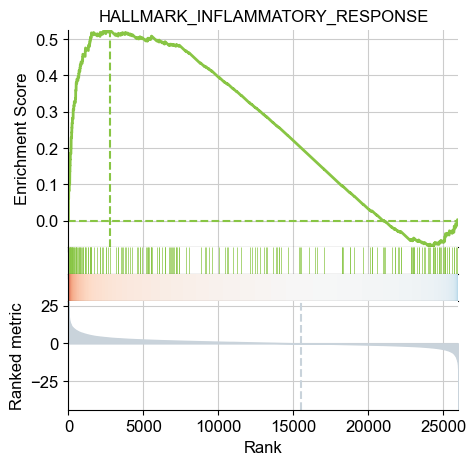

In [38]:
markers.index = markers['Scar/keloid_names']
dc.plot_running_score(
    df=markers,
    stat='Scar/keloid_scores',
    net=msigdb,
    source='source',
    target='target',
    set_name="HALLMARK_INFLAMMATORY_RESPONSE", save="./4.2.Figure1H_1.pdf")

In [40]:
msigdb = dc.read_gmt("../../../Data/msigdb_v2024.1.Hs_GMTs/c2.cp.reactome.v2024.1.Hs.symbols.gmt")
msigdb = msigdb[~msigdb.duplicated(['source',"target"])]
tmp = []
for i in msigdb['source']:
    if "_" in i:
        tmp.append(i[:i.find("_")])
    else:
        tmp.append(i)
msigdb['collection']=tmp
print(msigdb['collection'].unique().tolist())

['REACTOME']


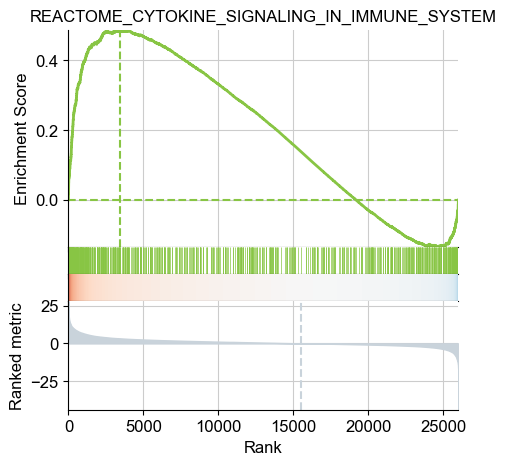

In [41]:
markers.index = markers['Scar/keloid_names']
dc.plot_running_score(
    df=markers,
    stat='Scar/keloid_scores',
    net=msigdb,
    source='source',
    target='target',
    set_name="REACTOME_CYTOKINE_SIGNALING_IN_IMMUNE_SYSTEM", save="./4.2.Figure1H_2.pdf.pdf")

In [42]:
!conda list

# packages in environment at C:\Users\dell\.conda\envs\scanpy:
#
# Name                    Version                   Build  Channel
absl-py                   2.3.0                    pypi_0    pypi
adjusttext                1.3.0                    pypi_0    pypi
aiobotocore               2.5.4                    pypi_0    pypi
aiohappyeyeballs          2.6.1                    pypi_0    pypi
aiohttp                   3.12.4                   pypi_0    pypi
aioitertools              0.12.0                   pypi_0    pypi
aiosignal                 1.3.2                    pypi_0    pypi
anndata                   0.10.8                   pypi_0    pypi
anyio                     4.8.0                    pypi_0    pypi
argon2-cffi               23.1.0                   pypi_0    pypi
argon2-cffi-bindings      21.2.0                   pypi_0    pypi
array-api-compat          1.10.0                   pypi_0    pypi
arrow                     1.3.0                    pypi_0    pypi
asciitree 